# 03b Pre-Knockout Network Optimization Analysis

This notebook compares optimization objectives before knockout while also showing archive priors from the elite PGN source corpus.

- Inspect the source-game mix that will dominate future fine-tuning.
- Build a tabular surrogate dataset from Nagato training entries.
- Train the same network with `MSELoss` and `HuberLoss`.
- Plot prediction-vs-target density at three zoom levels (wide, medium, tight).

Source inspiration: www.youtube.com/watch?v=5vsLmM756LA

In [1]:
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

root = Path.cwd()
sys.path.append(str(root / 'training'))
import nnue_lab_common as c

sns.set_theme(style='whitegrid')
device = c.device()
print('device:', device)

device: mps


In [2]:
archive_sample = c.sample_elite_headers(max_games_per_file=120).copy()
top_openings = archive_sample['opening'].value_counts().head(6).index
archive_sample['opening_bucket'] = np.where(
    archive_sample['opening'].isin(top_openings),
    archive_sample['opening'],
    'Other',
)

display(
    archive_sample[['month', 'result', 'tc_class', 'opening_bucket', 'avg_elo']].head()
 )
print('Archive sample size:', len(archive_sample))
print('Fast-game share:', round(float(archive_sample['tc_class'].isin(['bullet', 'blitz']).mean()), 3))

,month,result,tc_class,opening_bucket,avg_elo
0,2013-09,1-0,blitz,Scandinavian Defense: Main Line,2341.0
1,2013-09,0-1,blitz,Other,2340.5
2,2013-09,0-1,blitz,Other,2341.5
3,2013-09,1-0,blitz,Scandinavian Defense: Main Line,2342.0
4,2013-09,0-1,blitz,Other,2368.0


Archive sample size: 8784
Fast-game share: 0.993


In [3]:
def build_tabular_from_bin(path, max_entries=120000, stride=8):
    rows = []
    with open(path, 'rb') as f:
        i = 0
        while len(rows) < max_entries:
            raw = f.read(c.ENTRY_SIZE)
            if not raw:
                break
            if i % stride == 0:
                p = c.parse_entry(raw)
                pc = p['piece_counts']
                rows.append([
                    pc[0], pc[1], pc[2], pc[3], pc[4],
                    pc[5], pc[6], pc[7], pc[8], pc[9],
                    p['stm'], p['pieces'],
                    len(p['white_feats']), len(p['black_feats']),
                ])
            i += 1
    columns = [
        'wp', 'wn', 'wb', 'wr', 'wq',
        'bp', 'bn', 'bb', 'br', 'bq',
        'stm', 'pieces', 'wfc', 'bfc',
    ]
    X = pd.DataFrame(rows, columns=columns)
    return X

train_file = c.default_training_file()
X = build_tabular_from_bin(train_file, max_entries=120000, stride=8)

# Targets in pawns with wider spread for optimization comparison plots.
mat = (
    3.4 * (X['wq'] - X['bq'])
    + 1.9 * (X['wr'] - X['br'])
    + 1.2 * (X['wb'] - X['bb'])
    + 1.0 * (X['wn'] - X['bn'])
    + 0.23 * (X['wp'] - X['bp'])
)
phase = 0.12 * (X['pieces'] - 20)
activity = 0.05 * (X['wfc'] - X['bfc'])
stm_term = np.where(X['stm'] > 0, -0.35, 0.35)
noise = np.random.normal(0.0, 1.4, size=len(X))
y_series = np.clip(mat + phase + activity + stm_term + noise, -22, 22)
y = np.asarray(y_series, dtype=np.float32)

split = int(0.2 * len(X))
X_test_raw = X.iloc[:split].copy()
X_train_raw = X.iloc[split:].copy()
y_test = y[:split]
y_train = y[split:]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0).replace(0, 1.0)
X_train = ((X_train_raw - mu) / sigma).to_numpy(dtype=np.float32)
X_test = ((X_test_raw - mu) / sigma).to_numpy(dtype=np.float32)

print('train', X_train.shape, y_train.shape)
print('test ', X_test.shape, y_test.shape)
print('target std:', float(np.std(y_train)))

train (96000, 14) (96000,)
test  (24000, 14) (24000,)
target std: 1.8964979648590088


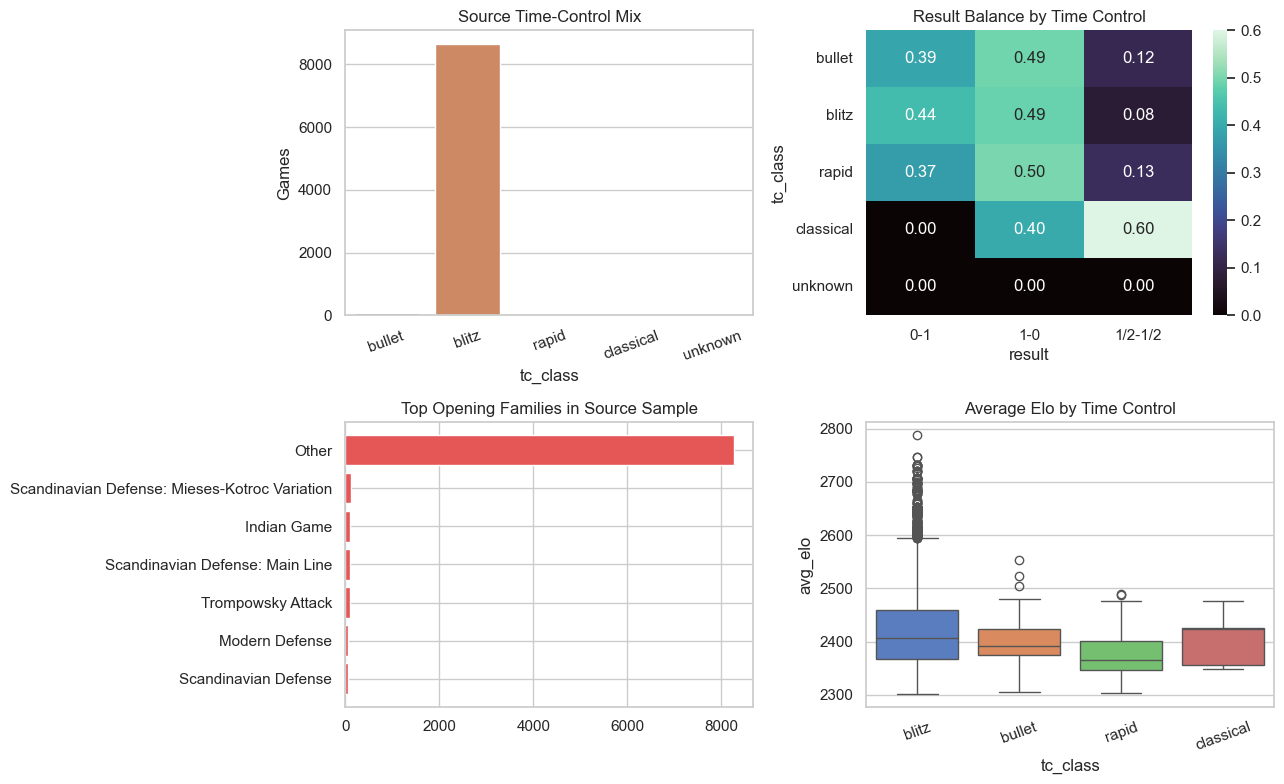

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

tc_counts = archive_sample['tc_class'].value_counts().reindex(['bullet', 'blitz', 'rapid', 'classical', 'unknown'], fill_value=0)
sns.barplot(x=tc_counts.index, y=tc_counts.values, hue=tc_counts.index, palette='deep', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Source Time-Control Mix')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].set_ylabel('Games')

result_mix = pd.crosstab(archive_sample['tc_class'], archive_sample['result'], normalize='index').reindex(tc_counts.index, fill_value=0.0)
sns.heatmap(result_mix, annot=True, fmt='.2f', cmap='mako', ax=axes[0, 1])
axes[0, 1].set_title('Result Balance by Time Control')

opening_counts = archive_sample['opening_bucket'].value_counts().sort_values()
axes[1, 0].barh(opening_counts.index, opening_counts.values, color='#E45756')
axes[1, 0].set_title('Top Opening Families in Source Sample')

elo_frame = archive_sample.dropna(subset=['avg_elo']).copy()
sns.boxplot(data=elo_frame, x='tc_class', y='avg_elo', hue='tc_class', legend=False, palette='muted', ax=axes[1, 1])
axes[1, 1].set_title('Average Elo by Time Control')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [5]:
class TinyNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32), nn.LeakyReLU(),
            nn.Linear(32, 32), nn.LeakyReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


def fit_model(loss_name='mse', epochs=5, batch_size=1024, lr=1e-2):
    model = TinyNet(X_train.shape[1]).to(device)
    opt = optim.SGD(model.parameters(), lr=lr)
    if loss_name == 'mse':
        criterion = nn.MSELoss()
    else:
        criterion = nn.HuberLoss(delta=1.0)

    Xt = torch.tensor(X_train, device=device)
    yt = torch.tensor(y_train[:, None], device=device)

    losses = []
    model.train()
    for _ in range(epochs):
        order = torch.randperm(Xt.size(0), device=device)
        epoch_loss = 0.0
        for start in range(0, Xt.size(0), batch_size):
            idx = order[start:start + batch_size]
            xb = Xt[idx]
            yb = yt[idx]
            pred = model(xb)
            loss = criterion(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * xb.size(0)
        losses.append(epoch_loss / Xt.size(0))

    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(X_test, device=device)).squeeze(1).cpu().numpy()
    return model, losses, pred

start = time.time()
m_model, m_losses, mpred = fit_model(loss_name='mse', epochs=5, batch_size=1024, lr=1e-2)
h_model, h_losses, hpred = fit_model(loss_name='huber', epochs=5, batch_size=1024, lr=1e-2)
print('mse   loss:', m_losses[-1])
print('huber loss:', h_losses[-1])
print('CPU times: total:', round(time.time() - start, 2), 's')

mse   loss: 2.07985085995992
huber loss: 0.9185784772237142
CPU times: total: 3.82 s


mse (24000,) (24000,)
huber (24000,) (24000,)


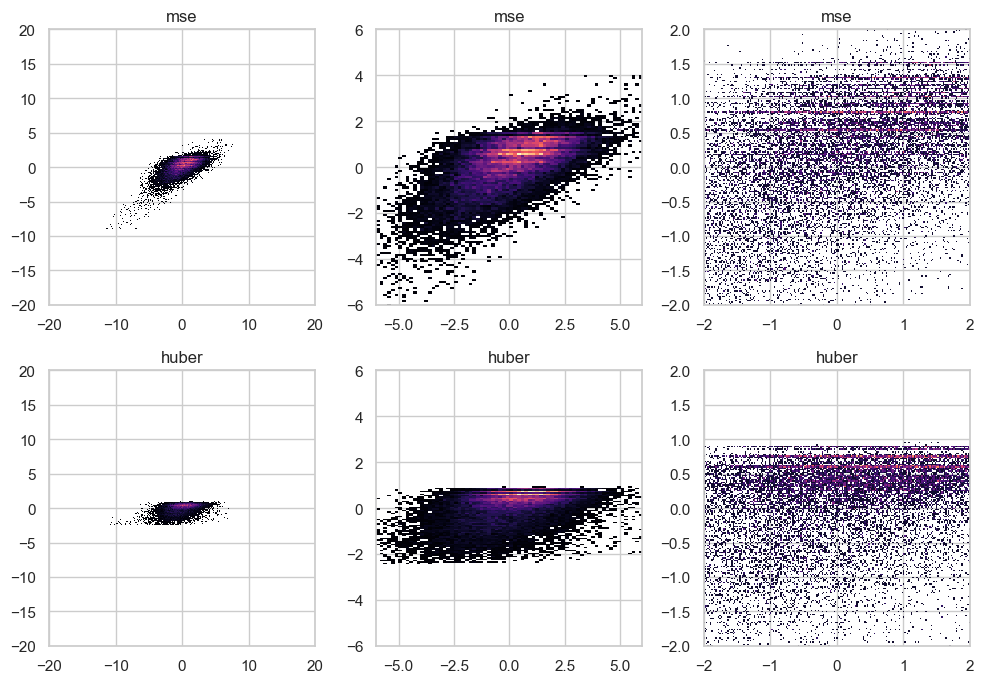

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 7))

for i, (name, pred) in enumerate([('mse', mpred), ('huber', hpred)]):
    print(name, pred.shape, y_test.shape)

    sns.histplot(x=y_test, y=pred, cmap='magma', ax=axes[i, 0])
    axes[i, 0].set_xlim(-20, 20)
    axes[i, 0].set_ylim(-20, 20)
    axes[i, 0].set_title(name)

    sns.histplot(x=y_test, y=pred, cmap='magma', ax=axes[i, 1])
    axes[i, 1].set_xlim(-6, 6)
    axes[i, 1].set_ylim(-6, 6)
    axes[i, 1].set_title(name)

    sns.histplot(x=y_test, y=pred, cmap='magma', ax=axes[i, 2], binwidth=0.02)
    axes[i, 2].set_xlim(-2, 2)
    axes[i, 2].set_ylim(-2, 2)
    axes[i, 2].set_title(name)

plt.tight_layout()
plt.show()

## LMP + Futility Tuning (5-Step Analysis)

1. Define a conservative search space for tight LMP and forward futility gates.
2. Build a stability proxy from model residuals (tail risk as tactical fragility).
3. Score each candidate on speed gain vs. estimated tactical risk.
4. Keep Pareto-optimal candidates and rank them with a stability-first objective.
5. Emit a recommended config for engine A/B validation.

In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: conservative/tight candidate grid
search_space = {
    "lmp_depth_max": [1, 2],
    "lmp_base": [6, 8, 10],
    "lmp_step": [2, 3],
    "fut_depth_max": [1, 2],
    "fut_margin_base": [100, 120, 140],
    "fut_margin_step": [40, 60],
    "improving_bonus": [20, 30, 40],
}

keys = list(search_space.keys())
rows = [dict(zip(keys, vals)) for vals in itertools.product(*[search_space[k] for k in keys])]
candidates = pd.DataFrame(rows)

# Step 2: stability proxy from residual tails (higher tail => more tactical fragility)
residual = np.abs((y_test - hpred).astype(np.float32))
res_q90 = float(np.quantile(residual, 0.90))
res_q95 = float(np.quantile(residual, 0.95))
tail_pressure = res_q95 / max(res_q90, 1e-6)

# Fast-game heavy sources should prefer extra stability guards
fast_share = float((archive_sample["tc_class"].isin(["bullet", "blitz"]).mean()))

# Step 3: surrogate speed/risk model
# Lower depth limits and larger margins are safer; higher LMP thresholds are riskier.
def evaluate_candidate(c):
    lmp_aggr = c.lmp_base + c.lmp_step * c.lmp_depth_max
    fut_aggr = c.fut_margin_base + c.fut_margin_step * c.fut_depth_max - c.improving_bonus

    # Approximate relative node reduction (good)
    speed_gain = (
        0.9 * (lmp_aggr / 20.0)
        + 1.1 * ((240.0 - fut_aggr) / 180.0)
    )

    # Approximate tactical risk (bad)
    risk = (
        1.2 * (lmp_aggr / 20.0)
        + 1.4 * ((220.0 - fut_aggr) / 180.0)
        + 0.7 * (tail_pressure - 1.0)
        + 0.3 * fast_share
    )

    # Stability-first utility, still rewarding speed.
    utility = 0.45 * speed_gain - 1.00 * risk
    return pd.Series({"speed_gain": speed_gain, "risk": risk, "utility": utility})

scores = candidates.apply(evaluate_candidate, axis=1)
results = pd.concat([candidates, scores], axis=1)

print(f"Candidates: {len(results)}")
print(f"Residual tail pressure (q95/q90): {tail_pressure:.3f}")
print(f"Fast-game share: {fast_share:.3f}")
results.head()

In [ ]:
# Step 4: Pareto filter (maximize speed_gain, minimize risk)
def pareto_front(df):
    keep = np.ones(len(df), dtype=bool)
    vals = df[["speed_gain", "risk"]].to_numpy()
    for i in range(len(vals)):
        if not keep[i]:
            continue
        dominated = (
            (vals[:, 0] >= vals[i, 0])
            & (vals[:, 1] <= vals[i, 1])
            & ((vals[:, 0] > vals[i, 0]) | (vals[:, 1] < vals[i, 1]))
        )
        if dominated.any():
            keep[i] = False
    return df.loc[keep].copy()

pareto = pareto_front(results).sort_values(["utility", "risk"], ascending=[False, True])

# Step 5: Recommend a tight, stability-first config from Pareto set
best = pareto.iloc[0]

print("Top Pareto candidates (stability-first):")
display(pareto.head(10))

print("\nRecommended tight config for engine A/B:")
print({
    "lmp_depth_max": int(best.lmp_depth_max),
    "lmp_base": int(best.lmp_base),
    "lmp_step": int(best.lmp_step),
    "fut_depth_max": int(best.fut_depth_max),
    "fut_margin_base": int(best.fut_margin_base),
    "fut_margin_step": int(best.fut_margin_step),
    "improving_bonus": int(best.improving_bonus),
})

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(results["risk"], results["speed_gain"], s=18, alpha=0.25, label="all candidates")
ax.scatter(pareto["risk"], pareto["speed_gain"], s=40, alpha=0.9, label="pareto front")
ax.scatter([best.risk], [best.speed_gain], s=100, marker="*", label="recommended")
ax.set_xlabel("Estimated Tactical Risk (lower is better)")
ax.set_ylabel("Estimated Speed Gain (higher is better)")
ax.set_title("LMP/Futility Tight-Config Tradeoff")
ax.legend()
plt.show()